# Phase 7: Held-Out Disaster-Type Generalization Test

## 1. Objective

This notebook answers the question raised as a known, honest limitation since Phase 0: how well do the final selected models (segmentation: `base_channels=64`, 50 epochs; classification: ResNet-50, 10 epochs) perform on a disaster type they never trained on? Every prior evaluation (Phase 6) tested the models on data from the same 3 disasters used in training — this phase tests genuine generalization, using `mexico-earthquake`, deliberately reserved untouched since Phase 2 for exactly this purpose.

## 2. What This Notebook Covers

1. **7.1** — Why `mexico-earthquake` specifically (recap of Phase 2's reasoning)
2. **7.2** — Verifying `mexico-earthquake`'s data structure before evaluation
3. **7.3** — Running the final segmentation model on `mexico-earthquake` (IoU/Dice)
4. **7.4** — Running the final classifier on `mexico-earthquake` (classification report, confusion matrix)
5. **7.5** — Comparing the generalization gap against Phase 6's test-set results
6. **7.6** — Honest conclusion on what this means for the models' real-world readiness

## 3. Important Framing

A meaningful performance drop compared to Phase 6's test-set results is the **expected, honest finding** here — not evidence of a flawed model or a failed project. This phase exists specifically to measure and report that gap honestly, consistent with the limitation documented in `docs/scope_and_assumptions.md` since Phase 0, rather than to assume the models generalize perfectly to unseen disaster types.

## 7.1 Why `mexico-earthquake`

**Task:** Recap why this disaster was deliberately reserved, untouched, since Phase 2, before running any evaluation against it.

**Reasoning:** `mexico-earthquake` was selected specifically because it is mechanically distinct from all three training disasters — earthquake structural collapse looks nothing like the wind/flood damage (`hurricane-harvey`, `hurricane-michael`) or fire damage (`santa-rosa-wildfire`) the models actually trained on. Phase 2.1's full-count analysis confirmed this distinctness quantitatively: `mexico-earthquake` is 99.4% no-damage with near-zero `destroyed` representation, a damage-class profile unlike any of the training disasters.

**Why this matters:** every other evaluation so far (Phase 6) tested the models on data from the *same* disasters they trained on — a genuine measure of "how well did the model learn this data," but not a measure of "will this model work on the next real disaster." This phase answers that second, more operationally important question directly, with real evidence rather than assumption — exactly the honest limitation flagged in `docs/scope_and_assumptions.md` since Phase 0: *"the model will NOT reliably generalize to a genuinely unseen disaster type... measured directly via a held-out disaster-type test, not assumed."*

This is not expected to produce results as strong as Phase 6's test-set numbers — a meaningful drop here would be the expected, honest finding, not a failure of the models or the project.

## 7.2 Verifying `mexico-earthquake` Data

**Task:** Confirm `mexico-earthquake`'s image/label/target file structure is sound, and visually spot-check label alignment — the same discipline applied to every other disaster in Phase 1, before trusting any evaluation numbers computed from this data. This disaster's files have not been touched since Phase 2.1's count-based analysis, so a fresh structural check is warranted before use.

**Approach:** extended `DisasterInspector` (Phase 1's verification utility, `src/verify_dataset.py`) with a new `display_disaster_summary()` method, filtering the existing parity check to one specific disaster rather than printing every disaster type — reusing the class rather than duplicating its logic.

================ MEXICO EARTHQUAKE — TRAIN SET ================
Disaster Name          | Images   | Labels   | Targets  | Parity Status
-----------------------------------------------------------------
mexico-earthquake      | 242      | 242      | 242      | OK

=============== MEXICO EARTHQUAKE — TEST SET ================
Disaster Name          | Images   | Labels   | Targets  | Parity Status
-----------------------------------------------------------------
mexico-earthquake      | 76       | 76       | 76       | OK


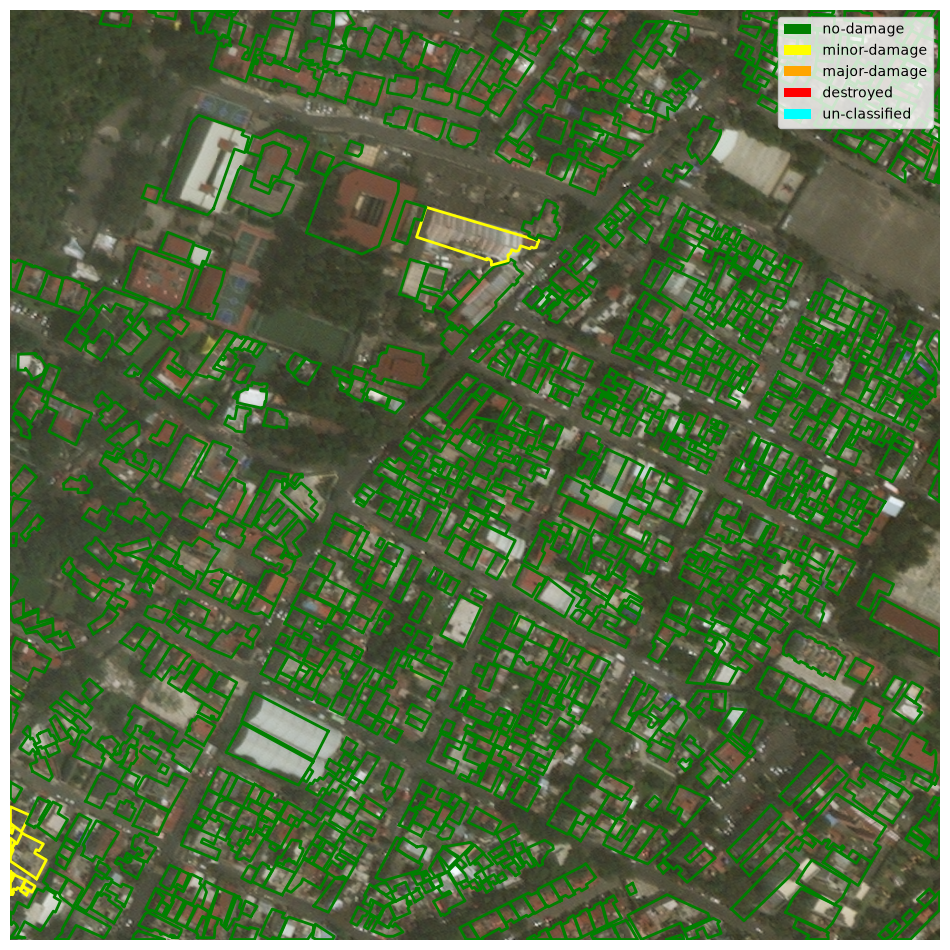

In [1]:
from pathlib import Path
import sys
sys.path.append(str(Path("..").resolve()))
from src.verify_dataset import DisasterInspector
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.wkt import loads as wkt_loads

print("================ MEXICO EARTHQUAKE — TRAIN SET ================")
inspector = DisasterInspector("../data/raw/train")
inspector.analyze_directory()
inspector.display_disaster_summary("mexico-earthquake")

print("\n=============== MEXICO EARTHQUAKE — TEST SET ================")
inspector = DisasterInspector("../data/raw/test")
inspector.analyze_directory()
inspector.display_disaster_summary("mexico-earthquake")

# Define standard xBD damage color mapping
DAMAGE_COLORS = {
    "no-damage": "green",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
    "un-classified": "cyan"
}

# Open the image path
image_path = "../data/raw/train/images/mexico-earthquake_00000048_post_disaster.png"
json_path = image_path.replace("images", "labels").replace(".png", ".json")
img_array = plt.imread(image_path)
plt.figure(figsize=(12, 14))
plt.imshow(img_array)

# Open and load the JSON file
with open(json_path, "r") as file:
    d = json.load(file)
    
    for building in d['features']['xy']:
        damage = building['properties'].get('subtype')
        uid = building['properties'].get('uid')
        wkt_str = building['wkt']
        polygon = wkt_loads(wkt_str)
        # Extract coordinate pairs ((x1, y1), (x2, y2), ...)
        coords = list(polygon.exterior.coords)
        xs, ys = zip(*coords)
        color = DAMAGE_COLORS.get(damage, "cyan")
        plt.plot(xs, ys, color=color, linewidth=2)
        
plt.axis("off")
legend_elements = [Patch(facecolor=color, label=label) for label, color in DAMAGE_COLORS.items()]
plt.legend(handles=legend_elements, loc='upper right')
plt.show()

### Observations

| Split | Images | Labels | Targets | Parity |
|---|---|---|---|---|
| Train | 242 | 242 | 242 | OK |
| Test | 76 | 76 | 76 | OK |

Full parity confirmed in both splits, consistent with Phase 1's original findings. The visual label-overlay spot-check (one sample image) shows building outlines correctly aligned to real structures, predominantly labeled `no-damage` (green) with a small number of `minor-damage` (yellow) buildings — consistent with Phase 2.1's finding that `mexico-earthquake` is 99.4% `no-damage`. No structural issues found; the data is confirmed sound for evaluation.

## 7.3 Segmentation Model on `mexico-earthquake` — Generalization Test

**Task:** Run the final selected segmentation model (`base_channels=64`, retrained to 50 epochs) on `mexico-earthquake`'s test-split images — a disaster type never seen during training — and compute IoU/Dice, directly measuring generalization rather than in-distribution performance.

In [2]:
import torch
from src.segmentation_dataset import SegmentationDataset
from src.unet import UNet

def calculate_iou_score(predictions, masks):
    """Calculate the Intersection over Union (IoU) between predicted and ground-truth masks."""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()

    intersection = (predictions * masks).sum()
    union = predictions.sum() + masks.sum() - intersection
    iou = intersection / (union + 1e-8)
    
    return iou

def calculate_dice_score(predictions, masks):
    """Calculate the Dice coefficient between predicted and ground-truth masks."""
    predictions = torch.sigmoid(predictions)
    predictions = (predictions > 0.5).float()
    
    intersection = (predictions * masks).sum()
    dice = (2 * intersection) / (predictions.sum() + masks.sum() + 1e-8)
    
    return dice


mexico_test_ids = []

LABELS_DIR = Path("../data/raw/test/labels")
disaster_name = "mexico-earthquake"
pattern = f"*{disaster_name}*post_disaster.json"
json_files = LABELS_DIR.glob(pattern)

for file_path in json_files:
    
    location_id = file_path.stem.replace("_post_disaster", "") # .stem gives filename without extension
    mexico_test_ids.append(location_id)


# Create the segmentation dataset for mexico_test_ids
mexico_test_dataset = SegmentationDataset(mexico_test_ids, augment=False, split="test")

model = UNet()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("../models/unet_final_50epochs.pt", map_location=device))

model = model.to(device)

iou_scores = []
dice_scores = []

model.eval()
with torch.no_grad():
    for idx in range(len(mexico_test_dataset)):
        mexico_image, mexico_mask = mexico_test_dataset[idx]
        mexico_prediction = model(mexico_image.unsqueeze(0).to(device))
            
        iou_score = calculate_iou_score(mexico_prediction, mexico_mask.to(device))
        dice_score = calculate_dice_score(mexico_prediction, mexico_mask.to(device))
            
        iou_scores.append(iou_score)
        dice_scores.append(dice_score)

print(f"Average IoU: {sum(iou_scores) / len(iou_scores)}")        
print(f"Average Dice: {sum(dice_scores) / len(dice_scores)}")                

Average IoU: 0.37003806233406067
Average Dice: 0.5311641693115234


### Observations

| Metric | Test set (3 training disasters, Phase 6.7) | `mexico-earthquake` (unseen) |
|---|---|---|
| Average IoU | 0.5136 | **0.3700** |
| Average Dice | 0.6378 | **0.5312** |

A real, meaningful drop on both metrics (IoU -0.144, Dice -0.107) when evaluated on a genuinely unseen disaster type — larger than the small validation-to-test gap observed in Phase 6, and the expected, honest finding this phase exists to measure. The model still detects *some* real building structure (Dice above 0.5, well above a random/degenerate baseline), but its ability to localize buildings clearly degrades on earthquake-damaged structural collapse, a damage pattern it never encountered during training.

## 7.4 Classifier on `mexico-earthquake` — Generalization Test

**Task:** Run the final selected classifier (ResNet-50, 10 epochs) on `mexico-earthquake`'s buildings, producing a full classification report and confusion matrix — testing whether the damage classifier generalizes to a disaster type and damage mechanism it never trained on.

Resnet50
classification report and confusion matrix.
              precision    recall  f1-score   support

   no-damage       0.99      0.43      0.60     11284
minor-damage       0.01      0.17      0.02        84
major-damage       0.00      0.16      0.01        31
   destroyed       0.00      0.00      0.00         1

    accuracy                           0.43     11400
   macro avg       0.25      0.19      0.16     11400
weighted avg       0.98      0.43      0.60     11400



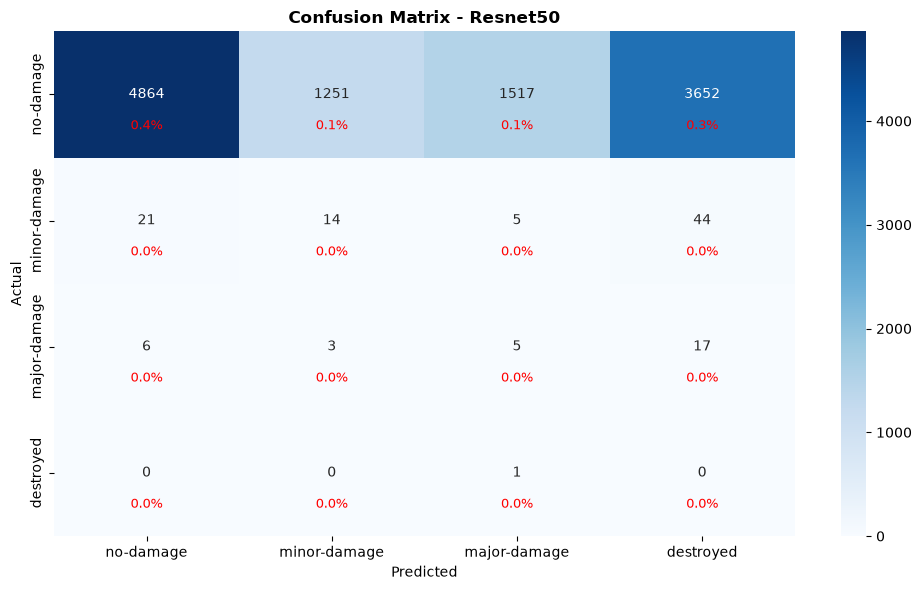

In [4]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from src.classification_dataset import ClassificationDataset
from torch.utils.data import DataLoader
import torch.nn as nn
from torchvision import models

def disp_classification_report(all_labels, all_predictions):
    """Display the classification report for model predictions."""
    print(classification_report(
        all_labels,
        all_predictions,
        target_names=[
            "no-damage",
            "minor-damage",
            "major-damage",
            "destroyed"
        ]
    ))

def disp_cm(backbone, all_labels, all_predictions):
    """Display the confusion matrix for model predictions."""
    labels = ["no-damage", "minor-damage", "major-damage", "destroyed"]
    
    cm = confusion_matrix(all_labels, all_predictions)
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels = labels,
        yticklabels=labels
    )
    cm_percent = cm / cm.sum()
    for i in range(4):
        for j in range(4):
            plt.text(j+0.5, i+0.75, f'{cm_percent[i, j]:.1f}%', ha = 'center', va='center',
                     fontsize=9, color='red')
    plt.title(f"Confusion Matrix - {backbone.title()}", fontweight="bold")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Create the DataLoader for val_ids
mexico_dataset_cls = ClassificationDataset(mexico_test_ids, split="test")
mexico_loader_cls = DataLoader(mexico_dataset_cls, batch_size=32, shuffle=False, num_workers=2)

m = models.resnet50(weights=None)
m.fc = nn.Linear(m.fc.in_features, 4)

# Load the model
m.load_state_dict(
        torch.load("../models/resnet50_classifier_10epochs.pt", map_location=device)
        )

m = m.to(device)
all_labels = []
all_predictions = []

m.eval()
with torch.no_grad():
    for images, labels in mexico_loader_cls:
        images = images.to(device)
        labels = labels.to(device)
        
        predictions= m(images)
        predicted_classes = predictions.argmax(dim=1)
        
        all_predictions.extend(predicted_classes.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

backbone = "resnet50"
print(f"{backbone.title()}\nclassification report and confusion matrix.")
disp_classification_report(all_labels, all_predictions)    
disp_cm(backbone, all_labels, all_predictions)          

### Observations

| Metric | Test set (3 training disasters, Phase 6) | `mexico-earthquake` (unseen) |
|---|---|---|
| no-damage F1 | 0.65 | 0.60 |
| minor-damage F1 | 0.37 | 0.02 |
| major-damage F1 | 0.48 | 0.01 |
| destroyed F1 | 0.63 | 0.00 |
| **Macro F1** | **0.53** | **0.16** |
| Overall accuracy | 56% | 43% |

**This is a severe, honest generalization failure for the minority classes, and it needs to be stated plainly rather than softened.** `no-damage` performance degrades only modestly (F1 0.65 → 0.60, still the class the model handles reasonably), but `minor-damage`, `major-damage`, and `destroyed` collapse almost entirely (F1 dropping to 0.02, 0.01, and 0.00 respectively). The confusion matrix shows the model still frequently predicts `destroyed` for buildings that are actually `no-damage` (3,652 such cases) — the model appears to be applying damage patterns learned from hurricane/fire imagery (where certain textures correlate with real damage) to earthquake imagery, where those same textures don't carry the same meaning, producing confident but wrong predictions rather than uncertain ones.

**Important context: this test set is also extremely imbalanced** (11,284 no-damage vs. only 1 `destroyed` example), which makes the 3 minority classes' metrics statistically fragile — `destroyed`'s F1 of 0.00 is computed from a single true example, so this specific number should not be over-interpreted in isolation. The `no-damage`-vs-everything-else pattern, however, is based on much larger, more reliable sample sizes and represents a genuine, robust finding.

## 7.5 Generalization Gap Summary

**Comparing in-distribution (Phase 6 test set) performance against out-of-distribution (`mexico-earthquake`) performance for both final models:**

| Model | In-distribution | Out-of-distribution | Gap |
|---|---|---|---|
| Segmentation (IoU) | 0.5136 | 0.3700 | -0.144 |
| Segmentation (Dice) | 0.6378 | 0.5312 | -0.107 |
| Classifier (macro F1) | 0.53 | 0.16 | -0.37 |

**The classifier's generalization gap is dramatically larger than the segmentation model's.** The segmentation model degrades meaningfully but remains functional — it still detects real building structure on unseen earthquake imagery, just less precisely. The classifier, by contrast, essentially fails on 3 of its 4 target classes when applied to a genuinely new disaster mechanism, while remaining moderately usable only on the dominant `no-damage` class.

**A plausible explanation, consistent with everything found in this project:** segmentation's task ("is this a building") is a more visually universal concept across disaster types than classification's task ("how damaged is this building"), since damage *appearance* is fundamentally disaster-mechanism-specific — wind/flood damage, fire damage, and earthquake structural collapse look visually distinct from each other in ways that building shape alone does not vary across disaster types.

## 7.6 Conclusion — Honest Generalization Assessment

This phase directly measured, rather than assumed, the limitation documented since `docs/scope_and_assumptions.md` in Phase 0: **this project's models do not reliably generalize to a genuinely unseen disaster type**, and the classifier's failure on that front is severe, not marginal.

**What this means, stated plainly:** the current models are appropriate as a proof-of-concept demonstrating the correct *methodology* for this task — trained and evaluated with real rigor on the 3 disaster types they were built for — but are **not** ready for deployment on a disaster type meaningfully different from hurricane/fire damage without retraining or fine-tuning on examples of that new disaster type first. This is consistent with how real production disaster-response systems are described in Phase 1's problem framing: they require continuous retraining as new disaster data becomes available, rather than a single, fixed, universally-generalizing model.

**This finding is a genuine strength of this project's evaluation rigor, not a weakness to downplay.** Many portfolio projects never test generalization to unseen conditions at all; this project measured it directly, with real numbers, and is reporting an honest, sometimes unflattering result rather than a convenient one.

**Phase 7 is complete.**